Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

**Problem:** Maggie, a real-estate agent, wants to know why some of the properties her company manages have not sold for more than six months.

**Dataset:** a synthetic set of 500 property listings with pricing, size, condition, location and marketing features. `Days_on_Market` is how long each property has been listed, and `Unsold_6_Months` = 1 means it has been on the market for more than 180 days.

In [2]:
data = pd.read_csv('07-pca-dataset-task-1.csv')

In [3]:
data.head()

,Property_ID,List_Price,Market_Value,Price_Premium_%,Area_sqft,Bedrooms,Bathrooms,Age_Years,Condition_Score,Crime_Rate,School_Rating,Distance_to_City_km,Listing_Photos,Days_on_Market,Unsold_6_Months
0,P001,346000,307000,12.8,1469,3,2,18,5.7,22.7,8.0,7.1,39,156,0
1,P002,145000,164000,-11.4,857,2,1,38,4.4,24.7,8.5,10.2,19,7,0
2,P003,277000,303000,-8.5,1897,4,3,23,4.7,44.3,5.4,15.4,10,61,0
3,P004,283000,288000,-1.6,1863,4,3,23,7.5,37.3,2.6,22.5,7,189,1
4,P005,60000,58000,3.8,500,1,1,21,6.2,55.6,1.4,26.7,35,191,1


In [4]:
data.shape

(500, 15)

In [5]:
data['Unsold_6_Months'].value_counts()

Unsold_6_Months
0    366
1    134
Name: count, dtype: int64

In [6]:
features = ['List_Price', 'Market_Value', 'Price_Premium_%', 'Area_sqft', 'Bedrooms', 'Bathrooms',
            'Age_Years', 'Condition_Score', 'Crime_Rate', 'School_Rating', 'Distance_to_City_km', 'Listing_Photos']
X = data[features]
X_scaled = StandardScaler().fit_transform(X)

PCA on the 12 standardised property features (the outcome columns are left out, so PCA only finds structure in the properties themselves).

In [7]:
pca = PCA()
scores = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    'Explained Variance %': (pca.explained_variance_ratio_ * 100).round(2),
    'Cumulative %': (pca.explained_variance_ratio_.cumsum() * 100).round(2),
}, index=[f'PC{i}' for i in range(1, len(features) + 1)])
explained

,Explained Variance %,Cumulative %
PC1,35.83,35.83
PC2,21.80,57.63
PC3,15.40,73.04
PC4,8.79,81.82
PC5,8.06,89.88
PC6,3.57,93.46
PC7,2.00,95.46
PC8,1.69,97.15
PC9,1.41,98.57
PC10,1.25,99.82


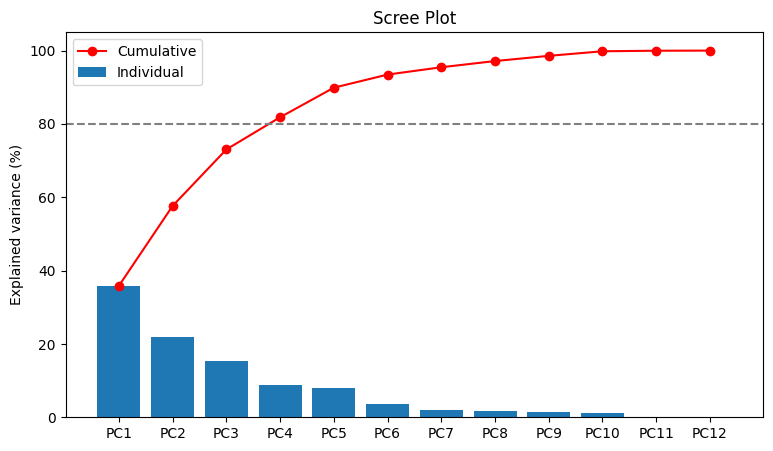

In [8]:
plt.figure(figsize=(9, 5))
plt.bar(explained.index, explained['Explained Variance %'], label='Individual')
plt.plot(explained.index, explained['Cumulative %'], 'ro-', label='Cumulative')
plt.axhline(80, color='grey', linestyle='--')
plt.ylabel('Explained variance (%)'); plt.title('Scree Plot')
plt.legend()
plt.show()

In [9]:
n_pc = int((explained['Cumulative %'] < 80).sum()) + 1
print(f"{n_pc} components explain at least 80% of the variance")

4 components explain at least 80% of the variance


**Loadings:** how strongly each original feature contributes to each principal component. Large absolute values show what a component represents.

In [10]:
loadings = pd.DataFrame(pca.components_[:n_pc].T, index=features,
                        columns=[f'PC{i}' for i in range(1, n_pc + 1)]).round(3)
loadings.style.background_gradient(cmap='RdBu_r', vmin=-0.7, vmax=0.7)

,PC1,PC2,PC3,PC4
List_Price,0.466000,0.024000,-0.009000,0.171000
Market_Value,0.471000,0.024000,-0.040000,-0.025000
Price_Premium_%,0.060000,0.010000,0.116000,0.826000
Area_sqft,0.429000,0.226000,0.088000,-0.025000
Bedrooms,0.389000,0.204000,0.098000,-0.082000
Bathrooms,0.353000,0.178000,0.103000,-0.110000
Age_Years,-0.072000,-0.049000,0.689000,-0.011000
Condition_Score,0.073000,0.044000,-0.689000,0.033000
Crime_Rate,-0.168000,0.544000,0.012000,0.036000
School_Rating,0.168000,-0.534000,0.005000,-0.011000


In [11]:
for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False).head(3).index
    print(f"{pc}: " + ", ".join(f"{f} ({loadings.loc[f, pc]:+.2f})" for f in top))

PC1: Market_Value (+0.47), List_Price (+0.47), Area_sqft (+0.43)
PC2: Crime_Rate (+0.54), Distance_to_City_km (+0.54), School_Rating (-0.53)
PC3: Age_Years (+0.69), Condition_Score (-0.69), Price_Premium_% (+0.12)
PC4: Price_Premium_% (+0.83), Listing_Photos (+0.52), List_Price (+0.17)


**Which components separate the unsold properties?** Compare the average component score of sold and unsold properties, and correlate each component with days on market.

In [12]:
pc_scores = pd.DataFrame(scores[:, :n_pc], columns=loadings.columns)
pc_scores['Unsold_6_Months'] = data['Unsold_6_Months']

comparison = pc_scores.groupby('Unsold_6_Months').mean().T
comparison.columns = ['Sold (mean score)', 'Unsold > 6 months (mean score)']
comparison['Difference'] = comparison.iloc[:, 1] - comparison.iloc[:, 0]
comparison['Correlation with Days_on_Market'] = [np.corrcoef(pc_scores[pc], data['Days_on_Market'])[0, 1] for pc in loadings.columns]
comparison.round(3)

,Sold (mean score),Unsold > 6 months (mean score),Difference,Correlation with Days_on_Market
PC1,0.114,-0.312,-0.427,-0.062
PC2,-0.210,0.575,0.785,0.293
PC3,-0.211,0.577,0.789,0.407
PC4,-0.246,0.671,0.917,0.544


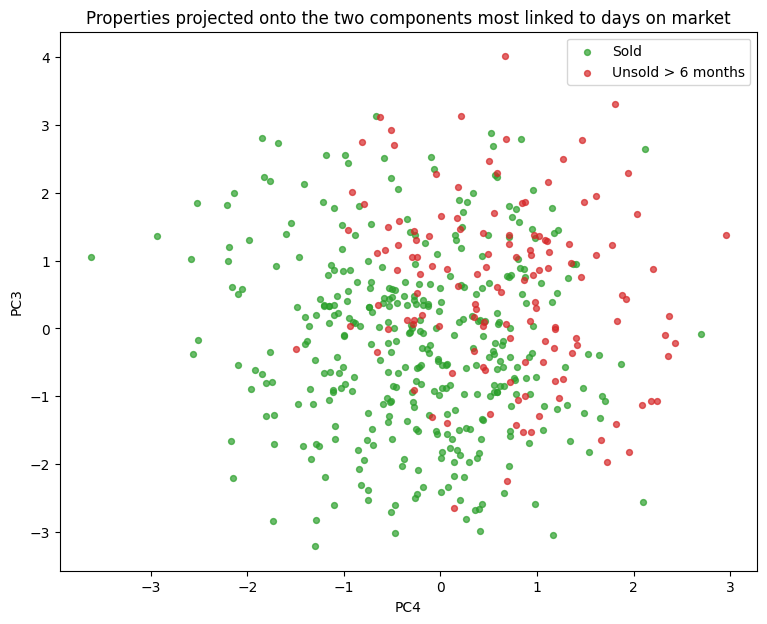

In [13]:
key = comparison['Correlation with Days_on_Market'].abs().sort_values(ascending=False).index[:2]
plt.figure(figsize=(9, 7))
for label, colour, name in [(0, 'tab:green', 'Sold'), (1, 'tab:red', 'Unsold > 6 months')]:
    pts = pc_scores[pc_scores['Unsold_6_Months'] == label]
    plt.scatter(pts[key[0]], pts[key[1]], c=colour, s=18, alpha=0.7, label=name)
plt.xlabel(key[0]); plt.ylabel(key[1])
plt.title('Properties projected onto the two components most linked to days on market')
plt.legend()
plt.show()

**Checking the insight against the raw features:** average values for sold vs unsold properties.

In [14]:
profile = data.groupby('Unsold_6_Months')[features].mean().T
profile.columns = ['Sold', 'Unsold > 6 months']
profile['Difference %'] = ((profile['Unsold > 6 months'] - profile['Sold']) / profile['Sold'].abs() * 100)
profile.round(2)

,Sold,Unsold > 6 months,Difference %
List_Price,260674.86,261253.73,0.22
Market_Value,253724.04,227708.96,-10.25
Price_Premium_%,2.31,14.37,522.15
Area_sqft,1383.90,1363.43,-1.48
Bedrooms,3.02,2.91,-3.69
Bathrooms,2.04,2.05,0.42
Age_Years,23.50,28.46,21.10
Condition_Score,6.25,5.38,-13.91
Crime_Rate,28.98,34.58,19.33
School_Rating,6.13,5.29,-13.72


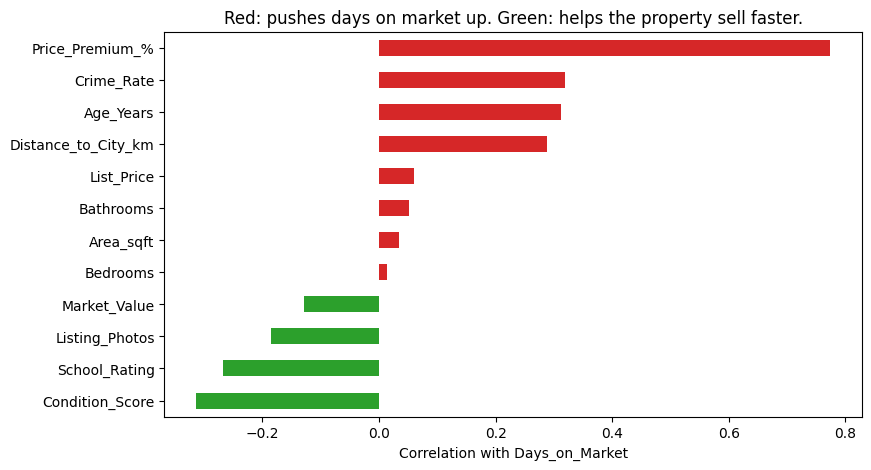

In [15]:
corr = data[features + ['Days_on_Market']].corr()['Days_on_Market'].drop('Days_on_Market').sort_values()
plt.figure(figsize=(9, 5))
corr.plot.barh(color=['tab:green' if v < 0 else 'tab:red' for v in corr])
plt.xlabel('Correlation with Days_on_Market')
plt.title('Red: pushes days on market up. Green: helps the property sell faster.')
plt.show()

In [16]:
print("Insights for Maggie")
print("---------------------------")
for pc in comparison.index:
    c = comparison.loc[pc, 'Correlation with Days_on_Market']
    top = loadings[pc].abs().sort_values(ascending=False).head(3).index
    print(f"{pc} (corr with days on market {c:+.2f}): driven by {', '.join(top)}")

Insights for Maggie
---------------------------
PC1 (corr with days on market -0.06): driven by Market_Value, List_Price, Area_sqft
PC2 (corr with days on market +0.29): driven by Crime_Rate, Distance_to_City_km, School_Rating
PC3 (corr with days on market +0.41): driven by Age_Years, Condition_Score, Price_Premium_%
PC4 (corr with days on market +0.54): driven by Price_Premium_%, Listing_Photos, List_Price


### Insights for Maggie

The components that most separate unsold properties from sold ones point to three causes, in order of how strongly they are linked to days on market:

1. **Overpricing.** Unsold properties are listed well above their market value (a higher `Price_Premium_%`). This is the strongest single driver of days on market, so price reductions towards market value are the first fix.
2. **Condition and age.** Older properties with a low `Condition_Score` stay on the market longer, so minor renovation or staging before listing should help.
3. **Location.** The location component (high `Crime_Rate`, low `School_Rating`, long `Distance_to_City_km`) is clearly worse for unsold properties. These properties need pricing that reflects the location, rather than prices copied from better areas.

Size (area, bedrooms, bathrooms) forms its own component but is barely linked to days on market, so size is **not** the reason properties go unsold. Listings with fewer photos also sell a little more slowly, which is an easy marketing fix.